# PFFDataset Usage Examples

This notebook demonstrates how to use the `PFFDataset` class for loading and processing data from football matches. The `PFFDataset` provides a convenient interface for loading tracking and event data, processing it, and storing intermediate results for efficient reuse.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

In [3]:
# Import necessary libraries

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Import the PFFDataset class
from PFFDataset_src.dataset import PFFDataset

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

## 1. Basic Usage

Let's start with the most basic usage of the `PFFDataset` class.

In [4]:
# Initialize the dataset for Premier League 2024-25 season
dataset = PFFDataset(competition='PL', season='24-25')

# Display basic information about the dataset
print("Dataset Information:")
print(dataset)
print(f"Available matches: {len(dataset)}")
print(f"Match IDs: {dataset.match_ids}")

Dataset Information:
PFFDataset(competition='PL', season='24-25', matches=240, version='v4_velocity_orientation_fix')
Available matches: 240
Match IDs: ['31995', '31996', '31997', '31998', '31999', '32000', '32001', '32002', '32003', '32004', '32005', '32006', '32007', '32008', '32009', '32010', '32011', '32012', '32013', '32014', '32015', '32016', '32017', '32018', '32019', '32020', '32021', '32022', '32023', '32024', '32025', '32026', '32027', '32028', '32029', '32030', '32031', '32032', '32033', '32034', '32035', '32036', '32037', '32038', '32039', '32040', '32041', '32042', '32043', '32044', '32045', '32046', '32047', '32048', '32049', '32050', '32051', '32052', '32053', '32054', '32055', '32056', '32057', '32058', '32059', '32060', '32061', '32062', '32063', '32064', '32065', '32066', '32067', '32068', '32069', '32070', '32071', '32072', '32073', '32074', '32075', '32076', '32077', '32078', '32079', '32080', '32081', '32082', '32083', '32084', '32085', '32086', '32087', '32088', '

In [5]:
import torch

torch.cuda.is_available()

True

In [6]:
# Build reusable processed triplets in parallel without keeping the whole season in memory
from os import cpu_count

triplet_builder = PFFDataset(competition='PL', season='24-25')
triplet_builder.load_data(
    add_velocity=True,
    event_type='all',
    save=True,
    overwrite=True,
    n_jobs=max(1, (cpu_count() or 2) - 1),
    store_in_memory=False,
)

print(f"Built or reused {len(triplet_builder.last_load_summary)} processed triplets")
print(f"Triplet root: {triplet_builder.save_path}")

# Load a single cached match into memory for interactive inspection in the rest of the notebook
sample_match_id = triplet_builder.match_ids[0]
dataset = PFFDataset(competition='PL', season='24-25')
dataset.load_data(
    match_ids=[sample_match_id],
    add_velocity=True,
    save=False,
    overwrite=False,
    store_in_memory=True,
)

print(f"Loaded {len(dataset.tracking)} match into memory")
print(f"Sample match: {sample_match_id}")
print(f"Events: {len(dataset.events[0])}")
print(f"Tracking frames: {len(dataset.tracking[0])}")
print(f"Players: {len(dataset.players[0])}")

Processing matches:   0%|          | 0/240 [00:00<?, ?match/s]

Processing matches: 100%|██████████| 240/240 [55:46<00:00, 13.94s/match]  


Built or reused 240 processed triplets
Triplet root: /home/joaomarcostomaz/causal/Simplified_EPV_in_PFF_Data/data/processed/pff_match_triplets/PL/24-25


Loading matches: 100%|██████████| 1/1 [00:00<00:00,  4.13it/s]

Loaded 1 match into memory
Sample match: 31995
Events: 1310
Tracking frames: 3779394
Players: 32


## 2. Loading Data with Different Parameters

The `load_data()` method accepts several parameters to customize data loading and processing:

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `n_matches` | `Optional[int]` | `None` | Number of matches to load (from start of list) |
| `match_ids` | `Optional[list[str]]` | `None` | Specific match IDs to load |
| `add_velocity` | `bool` | `False` | Calculate velocity features (slower but more detailed) |
| `event_type` | `str` | `'shot'` | Type of events to filter |
| `save` | `bool` | `True` | Cache processed data for reuse |
| `overwrite` | `bool` | `False` | Force reprocessing of cached data |

### Example 1: Load Specific Number of Matches

In [ ]:
dataset_small = PFFDataset(competition='PL', season='24-25')
dataset_small.load_data(n_matches=2)

print(f"Loaded {len(dataset_small.tracking)} matches")
print(f"Match IDs loaded: {[tracking['match_id'].iloc[0] if len(tracking) > 0 else 'empty' for tracking in dataset_small.tracking]}")

### Example 2: Load Specific Match IDs

In [ ]:
# Load specific matches by ID
specific_matches = ['32230', '32232']
dataset_specific = PFFDataset(competition='PL', season='24-25')
dataset_specific.load_data(match_ids=specific_matches)

print(f"Loaded {len(dataset_specific.tracking)} specific matches")
print(f"Match IDs loaded: {[tracking['match_id'].iloc[0] if len(tracking) > 0 else 'empty' for tracking in dataset_specific.tracking]}")

### Example 3: Force Reprocessing with Velocity Features

In [ ]:
# Force reprocessing with velocity features enabled
dataset_with_velocity = PFFDataset(competition='PL', season='24-25')
dataset_with_velocity.load_data(n_matches=1, add_velocity=True, overwrite=True)

print(f"Force reprocessed {len(dataset_with_velocity.tracking)} matches")
print("Useful when you want to reprocess data with different parameters")

### Example 4: Load Data Without Caching

In [ ]:
# Load data without saving to cache (for temporary analysis)
dataset_no_save = PFFDataset(competition='PL', season='24-25')
dataset_no_save.load_data(n_matches=1, save=False)

print(f"Loaded {len(dataset_no_save.tracking)} matches without saving to cache")
print("Useful for temporary analysis where you don't want to modify cached data")


### Example 5: Different Event Types (Future Implementation)

The following examples show how it will work once different event types are implemented:


In [ ]:
Example: Load data with pass events (not implemented yet)
dataset_pass = PFFDataset(competition='PL', season='24-25')
dataset_pass.load_data(n_matches=1, event_type='pass', save=False)
print(f"Loaded {len(dataset_pass.tracking)} matches with pass events")

In [ ]:
Example: Load data with multiple event types (not implemented yet)
dataset_events = PFFDataset(competition='PL', season='24-25')
dataset_events.load_data(n_matches=1, event_type=['pass', 'shot'], save=False)
print(f"Loaded {len(dataset_events.tracking)} matches with multiple event types")

In [ ]:
Example: Load data with all event types (not implemented yet)
dataset_all = PFFDataset(competition='PL', season='24-25')
dataset_all.load_data(n_matches=1, event_type='all', save=False)
print(f"Loaded {len(dataset_all.tracking)} matches with all event types")

## 3. Data Exploration

Let's explore the structure and content of the loaded data to understand what information is available.

In [7]:
# Let's use a dataset with some loaded data for exploration
exploration_dataset = PFFDataset(competition='PL', season='23-24')
exploration_dataset.load_data(n_matches=2)

if exploration_dataset.events:
    print("=== EVENTS DATA EXPLORATION ===")
    events_df = exploration_dataset.events[0]
    print(f"Events DataFrame shape: {events_df.shape}")
    print(f"\nEvents columns: {list(events_df.columns)}")
    print(f"\nFirst few rows:")
    print(events_df.head())

    print(f"\nEvent types distribution:")
    if 'possession_type' in events_df.columns:
        print(events_df['possession_type'].value_counts())

    print(f"\nOutcome distribution:")
    if 'outcome' in events_df.columns:
        print(events_df['outcome'].value_counts())

Loading matches:   0%|          | 0/2 [00:00<?, ?it/s]

Loading matches: 100%|██████████| 2/2 [00:00<00:00,  3.46it/s]

=== EVENTS DATA EXPLORATION ===
Events DataFrame shape: (1269, 52)

Events columns: ['match_id', 'event_id', 'possession_id', 'frame_id', 'start_frame_id', 'end_frame_id', 'period', 'elapsed_seconds', 'team_id', 'player_id', 'possession_type', 'x', 'y', 'ball_x', 'ball_y', 'ball_z', 'ball_height', 'set_piece', 'ball_x_start', 'ball_y_start', 'ball_z_start', 'ball_x_end', 'ball_y_end', 'ball_z_end', 'video_url', 'team_side', 'home_team_start_left', 'data_version', 'shot_outcome', 'shot_type', 'body_part', 'body_movement_type', 'ball_moving', 'nature_type', 'pass_type', 'pass_accuracy_type', 'receiver_player_id', 'target_player_id', 'no_look', 'creates_space', 'pressure_type', 'lines_broken_type', 'cross_type', 'cross_zone_type', 'cross_outcome', 'pass_outcome', 'carry_outcome', 'carry_type', 'carry_intent', 'carry_success', 'dribble_type', 'dribble_outcome']

First few rows:
   match_id  event_id  possession_id  frame_id  start_frame_id  end_frame_id  \
0     13335  12931923       12926

In [8]:
if exploration_dataset.tracking:
    print("\n=== TRACKING DATA EXPLORATION ===")
    tracking_df = exploration_dataset.tracking[0]
    print(f"Tracking DataFrame shape: {tracking_df.shape}")
    print(f"\nTracking columns: {list(tracking_df.columns)}")
    print(f"\nFirst few rows:")
    print(tracking_df.head())

    print(f"\nUnique players in tracking data:")
    if 'player_id' in tracking_df.columns:
        print(f"Number of unique players: {tracking_df['player_id'].nunique()}")
        print(f"Player IDs: {sorted(tracking_df['player_id'].unique())}")

    print(f"\nFrame information:")
    if 'frame_id' in tracking_df.columns:
        print(f"Number of frames: {tracking_df['frame_id'].nunique()}")
        print(f"Frame range: {tracking_df['frame_id'].min()} - {tracking_df['frame_id'].max()}")


=== TRACKING DATA EXPLORATION ===
Tracking DataFrame shape: (4080222, 26)

Tracking columns: ['match_id', 'frame_id', 'period', 'elapsed_seconds', 'team_id', 'player_id', 'x', 'y', 'ball_x', 'ball_y', 'ball_z', 'shirt', 'team_side', 'team_phase', 'vx', 'vy', 'ax', 'ay', 'speed', 'ball_vx', 'ball_vy', 'ball_vz', 'ball_speed', 'ball_ax', 'ball_ay', 'ball_az']

First few rows:
   match_id  frame_id  period  elapsed_seconds  team_id  player_id       x  \
0     13335      4612       1         0.000221      5.0      13068   0.713   
1     13335      4612       1         0.000221      5.0      14278   0.982   
2     13335      4612       1         0.000221      5.0      15620   0.087   
3     13335      4612       1         0.000221      5.0      19642  -0.439   
4     13335      4612       1         0.000221      5.0       2031 -18.955   

        y ball_x ball_y  ...  ax  ay speed ball_vx  ball_vy  ball_vz  \
0 -18.790   None   None  ... NaN NaN   NaN     NaN      NaN      NaN   
1 -25.356

In [9]:
if exploration_dataset.players:
    print("\n=== PLAYERS DATA EXPLORATION ===")
    players_df = exploration_dataset.players[0]
    print(f"Players DataFrame shape: {players_df.shape}")
    print(f"\nPlayers columns: {list(players_df.columns)}")
    print(f"\nFirst few rows:")
    print(players_df.head())

    print(f"\nTeam information:")
    if 'team_side' in players_df.columns:
        print(players_df['team_side'].value_counts())

    print(f"\nPosition information:")
    if 'position_name' in players_df.columns:
        print(players_df['position_name'].value_counts())


=== PLAYERS DATA EXPLORATION ===
Players DataFrame shape: (32, 4)

Players columns: ['player_id', 'shirt_number', 'team_side', 'position_name']

First few rows:
   player_id shirt_number team_side position_name
0        105            7      home            AM
1        118            5      home           RCB
2        127           20      home            LB
3        133            8      home            CF
4        136           10      home            LW

Team information:
team_side
home    16
away    16
Name: count, dtype: int64

Position information:
position_name
CM     7
CF     5
RCB    4
LW     3
RW     3
AM     2
LB     2
GK     2
LCB    2
RB     2
Name: count, dtype: int64


In [10]:
# Combine all events from multiple matches for analysis
if exploration_dataset.events:
    print("\n=== COMBINED DATA ANALYSIS ===")
    all_events = pd.concat(exploration_dataset.events, ignore_index=True)
    print(f"Total events across all matches: {len(all_events)}")

    # Basic statistics
    print(f"\nBasic statistics:")
    print(f"Number of matches: {all_events['match_id'].nunique()}")
    print(f"Number of unique players: {all_events['player_id'].nunique()}")

    # Shot analysis
    if 'outcome' in all_events.columns:
        print(f"\nShot outcomes:")
        print(all_events['outcome'].value_counts())

    if 'shot_type' in all_events.columns:
        print(f"\nShot types:")
        print(all_events['shot_type'].value_counts())

    # Location analysis
    if 'x' in all_events.columns and 'y' in all_events.columns:
        print(f"\nShot locations (x, y):")
        print(f"X range: {all_events['x'].min():.1f} - {all_events['x'].max():.1f}")
        print(f"Y range: {all_events['y'].min():.1f} - {all_events['y'].max():.1f}")
        print(f"Average location: ({all_events['x'].mean():.1f}, {all_events['y'].mean():.1f})")


=== COMBINED DATA ANALYSIS ===
Total events across all matches: 2600

Basic statistics:
Number of matches: 2
Number of unique players: 62

Shot types:
shot_type
shot            30
volley          12
side_shot        9
outside_foot     1
bycicle          1
low              1
Name: count, dtype: int64

Shot locations (x, y):
X range: -52.2 - 54.9
Y range: -36.1 - 36.9
Average location: (-3.2, 0.8)


## 4. Visualization Examples

The `PFFDataset` works seamlessly with the visualization functions in `visualization.py`. Let's explore different ways to visualize shot data:

### Available Visualization Functions:
- **`plot_shot_frame`**: Show individual shot frames with player positions
- **`plot_shot_heatmap`**: Create density heatmaps of shot locations  
- **`plot_multiple_shots`**: Display multiple shots in a grid layout


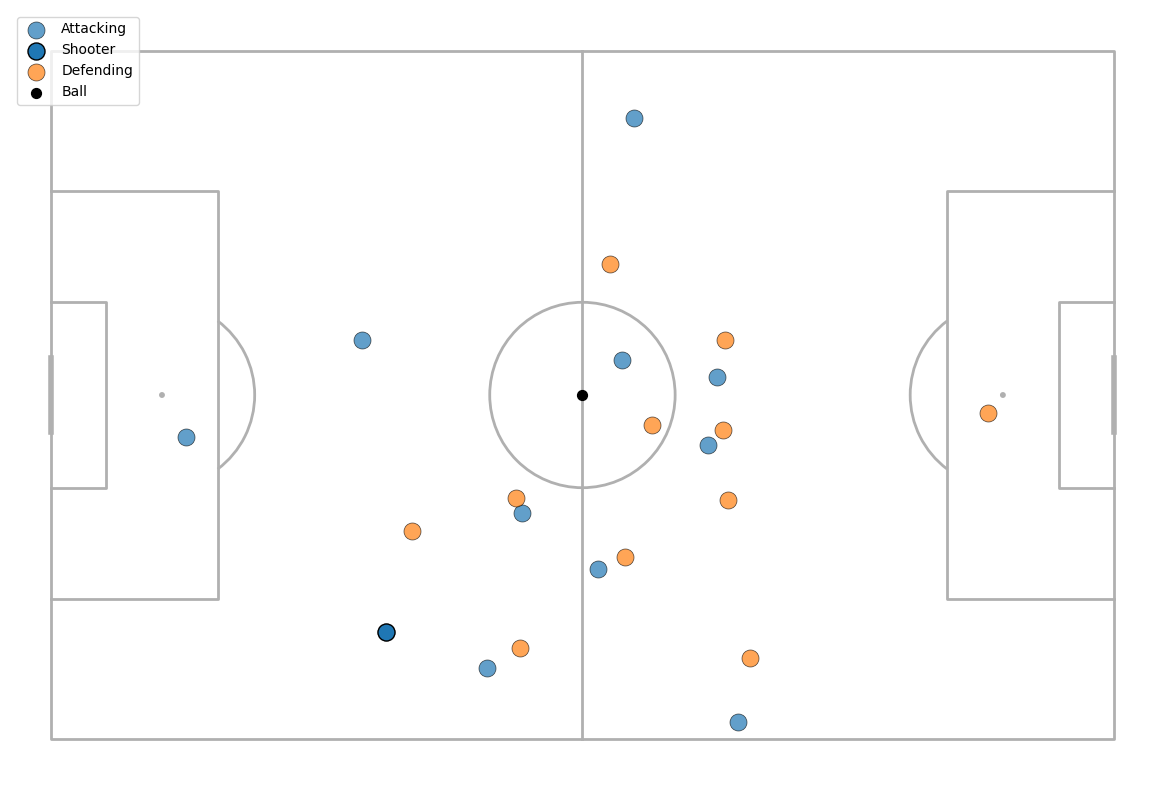

In [ ]:
# Import visualization functions
from Simplified_EPV_in_PFF_Data.PFFDataset_src_2.visualization import plot_shot_frame, plot_shot_heatmap

### Single Shot Frame Analysis
# Plot a single shot frame showing player positions and ball location
fig = plot_shot_frame(
    tracking_df=exploration_dataset.tracking[0],
    event_row=exploration_dataset.events[0].iloc[10],
    pitch_style='impect',
    show_players=True,
    show_ball=True
)

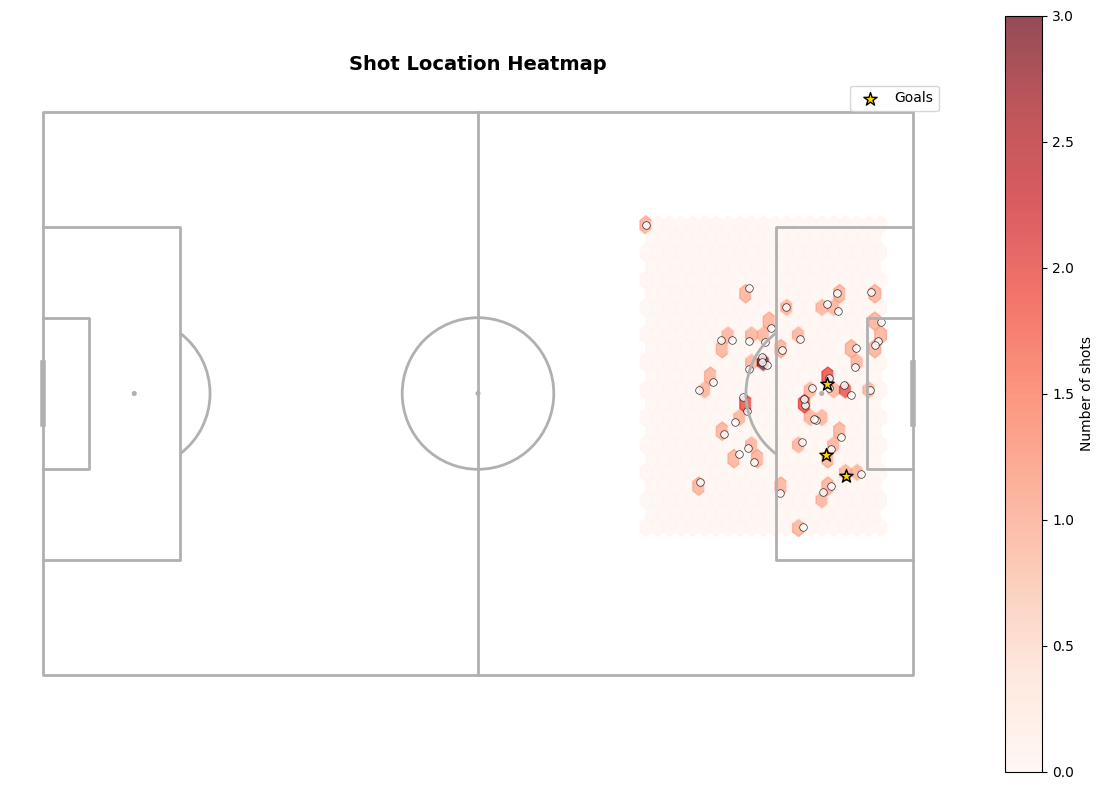

In [13]:
### Shot Density Heatmap
# Create a heatmap showing shot density across the pitch
all_events = pd.concat(exploration_dataset.events, ignore_index=True)

fig = plot_shot_heatmap(
    events_df=all_events,
    pitch_style='impect',
    figsize=(12, 8)
)
plt.show()

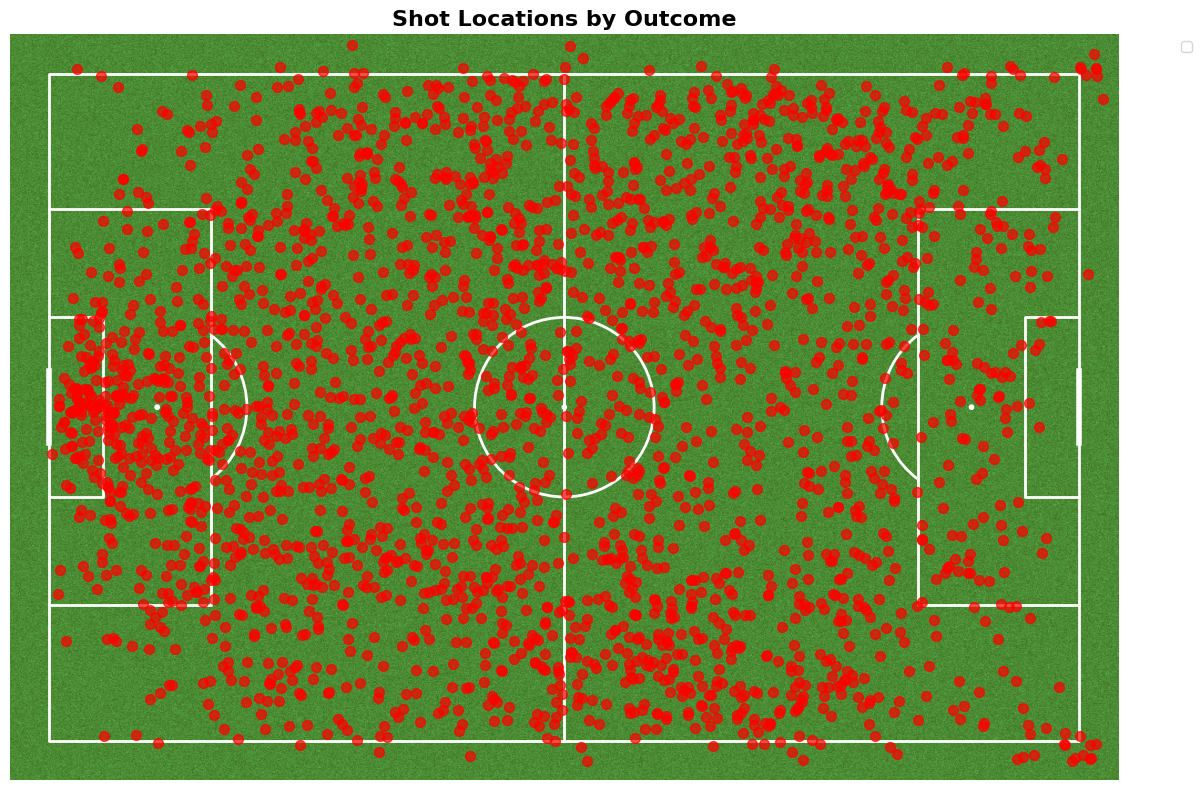

In [15]:
### Shot Locations Scatter Plot
# Create a scatter plot showing shot locations colored by outcome
from mplsoccer import Pitch

if exploration_dataset.events:
    all_events = pd.concat(exploration_dataset.events, ignore_index=True)

    # Create professional football pitch
    pitch = Pitch(pitch_type='impect', pitch_color='grass', line_color='white')
    fig, ax = pitch.draw(figsize=(12, 8))

    # Plot shot locations with smart color mapping
    if 'x' in all_events.columns and 'y' in all_events.columns:
        if 'outcome' in all_events.columns:
            outcomes = all_events['shot_outcome'].unique()

            # Smart color mapping: Goals always green
            color_map = {}
            available_colors = ['red', 'blue', 'orange', 'purple', 'brown', 'pink', 'gray']
            color_index = 0

            for outcome in outcomes:
                if 'goal' in outcome.lower():
                    color_map[outcome] = 'green'
                else:
                    color_map[outcome] = available_colors[color_index % len(available_colors)]
                    color_index += 1

            # Plot each outcome with assigned color
            for outcome in outcomes:
                mask = all_events['shot_outcome'] == outcome
                color = color_map[outcome]
                ax.scatter(all_events.loc[mask, 'x'], all_events.loc[mask, 'y'],
                          c=color, label=outcome, alpha=0.7, s=50)
        else:
            ax.scatter(all_events['x'], all_events['y'], alpha=0.7, s=50, c='red')

    plt.title('Shot Locations by Outcome', fontsize=16, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


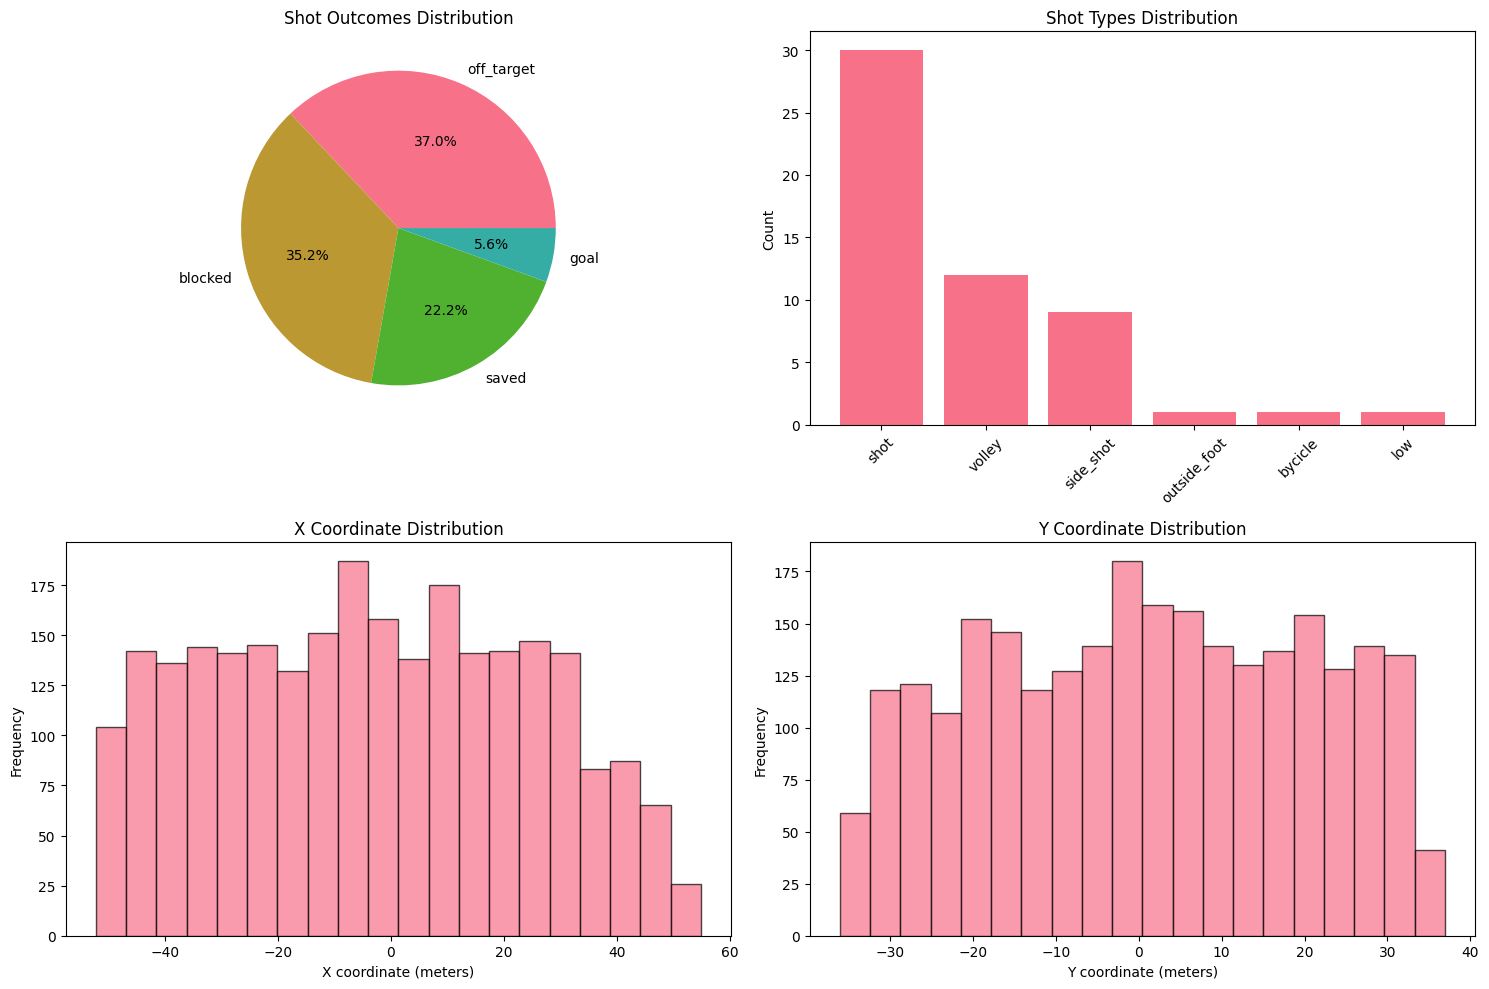

In [18]:
# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

if 'shot_outcome' in all_events.columns:
    # Outcome distribution
    outcome_counts = all_events['shot_outcome'].value_counts()
    axes[0, 0].pie(outcome_counts.values, labels=outcome_counts.index, autopct='%1.1f%%')
    axes[0, 0].set_title('Shot Outcomes Distribution')

if 'shot_type' in all_events.columns:
    # Shot type distribution
    shot_type_counts = all_events['shot_type'].value_counts()
    axes[0, 1].bar(range(len(shot_type_counts)), shot_type_counts.values)
    axes[0, 1].set_xticks(range(len(shot_type_counts)))
    axes[0, 1].set_xticklabels(shot_type_counts.index, rotation=45)
    axes[0, 1].set_title('Shot Types Distribution')
    axes[0, 1].set_ylabel('Count')

# X coordinate distribution
if 'x' in all_events.columns:
    axes[1, 0].hist(all_events['x'], bins=20, alpha=0.7, edgecolor='black')
    axes[1, 0].set_title('X Coordinate Distribution')
    axes[1, 0].set_xlabel('X coordinate (meters)')
    axes[1, 0].set_ylabel('Frequency')

# Y coordinate distribution
if 'y' in all_events.columns:
    axes[1, 1].hist(all_events['y'], bins=20, alpha=0.7, edgecolor='black')
    axes[1, 1].set_title('Y Coordinate Distribution')
    axes[1, 1].set_xlabel('Y coordinate (meters)')
    axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


## 5. Advanced Usage Patterns

Let's explore some advanced usage patterns and demonstrate how to work with the data effectively.


In [ ]:
# Advanced Example 1: Combining tracking and events data for detailed analysis
def analyze_shot_with_context(dataset, match_idx=0, shot_idx=0):
    """Analyze a specific shot with its tracking context."""

    if not dataset.events or match_idx >= len(dataset.events):
        print("No events data available")
        return None

    events_df = dataset.events[match_idx]
    tracking_df = dataset.tracking[match_idx]

    if shot_idx >= len(events_df):
        print(f"Shot index {shot_idx} out of range")
        return None

    shot_event = events_df.iloc[shot_idx]
    frame_id = shot_event['frame_id']

    # Get tracking data for this frame
    frame_tracking = tracking_df[tracking_df['frame_id'] == frame_id]

    print(f"=== SHOT ANALYSIS ===")
    print(f"Match ID: {shot_event['match_id']}")
    print(f"Frame ID: {frame_id}")
    print(f"Player ID: {shot_event['player_id']}")
    print(f"Outcome: {shot_event.get('outcome', 'N/A')}")
    print(f"Shot Type: {shot_event.get('shot_type', 'N/A')}")
    print(f"Location: ({shot_event['x']:.1f}, {shot_event['y']:.1f})")

    print(f"\nPlayers in frame: {len(frame_tracking)}")
    print(f"Ball position: ({frame_tracking['ball_x'].iloc[0]:.1f}, {frame_tracking['ball_y'].iloc[0]:.1f})")

    return shot_event, frame_tracking

# Example usage
if exploration_dataset.events and exploration_dataset.tracking:
    result = analyze_shot_with_context(exploration_dataset, match_idx=0, shot_idx=0)


In [ ]:
# Advanced Example 3: Custom data filtering and aggregation
def create_custom_shot_analysis(dataset):
    """Create custom analysis of shot data with filtering and aggregation."""

    if not dataset.events:
        return None

    # Combine all events
    all_events = pd.concat(dataset.events, ignore_index=True)

    # Custom filtering
    analysis = {}

    # Filter by shot type
    if 'shot_type' in all_events.columns:
        shot_types = all_events['shot_type'].value_counts()
        analysis['shot_types'] = shot_types

        # Analyze each shot type
        for shot_type in shot_types.index:
            shots_of_type = all_events[all_events['shot_type'] == shot_type]
            analysis[f'{shot_type}_stats'] = {
                'count': len(shots_of_type),
                'avg_x': shots_of_type['x'].mean() if 'x' in shots_of_type.columns else None,
                'avg_y': shots_of_type['y'].mean() if 'y' in shots_of_type.columns else None,
                'success_rate': (shots_of_type['outcome'] == 'goal').mean() if 'outcome' in shots_of_type.columns else None
            }

    # Filter by outcome
    if 'outcome' in all_events.columns:
        outcomes = all_events['outcome'].value_counts()
        analysis['outcomes'] = outcomes

        # Success rate by distance (if we can calculate distance)
        if 'x' in all_events.columns and 'y' in all_events.columns:
            # Simple distance calculation (distance from goal center)
            goal_center_x, goal_center_y = 105, 34  # Approximate goal center
            all_events['distance_to_goal'] = np.sqrt(
                (all_events['x'] - goal_center_x)**2 + (all_events['y'] - goal_center_y)**2
            )

            # Bin by distance
            distance_bins = [0, 10, 20, 30, 50, 100]
            all_events['distance_bin'] = pd.cut(all_events['distance_to_goal'], bins=distance_bins)

            success_by_distance = all_events.groupby('distance_bin')['outcome'].apply(
                lambda x: (x == 'goal').mean()
            )
            analysis['success_by_distance'] = success_by_distance

    return analysis

# Run the analysis
if exploration_dataset.events:
    custom_analysis = create_custom_shot_analysis(exploration_dataset)

    if custom_analysis:
        print("=== CUSTOM SHOT ANALYSIS ===")
        for key, value in custom_analysis.items():
            print(f"\n{key}:")
            print(value)

## 6. Best Practices

Here are some best practices for working with the `PFFDataset`:

In [ ]:
# Best Practice 1: Efficient data loading
def efficient_data_loading_example():
    """Demonstrate efficient data loading patterns."""

    print("=== EFFICIENT DATA LOADING ===")

    # 1. Always check available matches first
    dataset = PFFDataset(competition='PL', season='23-24')
    print(f"Available matches: {len(dataset)}")
    print(f"Match IDs: {dataset.match_ids}")

    # 2. Load in small batches for initial exploration
    print("\nLoading first 2 matches for exploration...")
    dataset.load_data(n_matches=2)

    # 3. Check data quality before loading more
    if dataset.events:
        total_events = sum(len(events) for events in dataset.events)
        print(f"Loaded {total_events} events across {len(dataset.tracking)} matches")

        # 4. Load more data only if needed
        if total_events < 50:  # Arbitrary threshold
            print("Loading more matches for better analysis...")
            dataset.load_data(n_matches=min(5, len(dataset)))

    return dataset

efficient_dataset = efficient_data_loading_example()


In [ ]:
# Best Practice 3: Error handling and data validation
def robust_data_processing(dataset):
    """Demonstrate robust data processing with error handling."""

    print("\n=== ROBUST DATA PROCESSING ===")

    # 1. Validate dataset before processing
    if not dataset.events:
        print("Error: No events data available")
        return None

    if not dataset.tracking:
        print("Error: No tracking data available")
        return None

    # 2. Check data consistency
    num_event_matches = len(dataset.events)
    num_tracking_matches = len(dataset.tracking)

    if num_event_matches != num_tracking_matches:
        print(f"Warning: Mismatch in number of matches - Events: {num_event_matches}, Tracking: {num_tracking_matches}")

    # 3. Process each match with error handling
    results = []

    for i, (events_df, tracking_df) in enumerate(zip(dataset.events, dataset.tracking)):
        try:
            print(f"Processing match {i+1}/{num_event_matches}...")

            # Validate data quality
            if len(events_df) == 0:
                print(f"  Warning: No events in match {i+1}")
                continue

            if len(tracking_df) == 0:
                print(f"  Warning: No tracking data in match {i+1}")
                continue

            # Check for required columns
            required_event_cols = ['match_id', 'frame_id', 'x', 'y']
            missing_cols = [col for col in required_event_cols if col not in events_df.columns]

            if missing_cols:
                print(f"  Warning: Missing columns in events data: {missing_cols}")
                continue

            # Perform analysis
            match_result = {
                'match_id': events_df['match_id'].iloc[0] if 'match_id' in events_df.columns else f"match_{i}",
                'num_events': len(events_df),
                'num_tracking_frames': len(tracking_df),
                'avg_x': events_df['x'].mean(),
                'avg_y': events_df['y'].mean()
            }

            results.append(match_result)

        except Exception as e:
            print(f"  Error processing match {i+1}: {e}")
            continue

    print(f"\nSuccessfully processed {len(results)} matches")
    return results

# Run robust processing
if efficient_dataset.events and efficient_dataset.tracking:
    robust_results = robust_data_processing(efficient_dataset)

    if robust_results:
        print("\nProcessing Results Summary:")
        for result in robust_results:
            print(f"  Match {result['match_id']}: {result['num_events']} events, avg location ({result['avg_x']:.1f}, {result['avg_y']:.1f})")
